# 04/21

캘리포니아 주택 가격

In [20]:
# %conda install scikit-learn pandas matplotlib

In [34]:
# 캘리포니아 주택 데이터 셋
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# 데이터 로드
housing = fetch_california_housing()
X = housing.data
y = housing.target

# 데이터 분리
x_train_full, x_test, y_train_full, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
x_train, x_valid, y_train, y_valid = train_test_split(x_train_full, y_train_full, test_size=0.25, random_state=42)

# 데이터 형태 확인
x_train.shape, x_valid.shape, x_test.shape

((11610, 8), (3870, 8), (5160, 8))

- 훈련데이터 가중치 학습
- 미니 배치 경사하강법 + 역전파
- 손실을 줄이도록 파라미터를 반복 업데이트

In [39]:
import tensorflow as tf
import numpy as np

In [52]:
import tensorflow as tf
tf.random.set_seed(42)

# 정규화 레이어
normal_layer = tf.keras.layers.Normalization(input_shape=(8,))

# 모델
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(8,)),
    normal_layer, 
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1)
])

# 컴파일
model.compile(
    loss='mse',
    optimizer='adam',
    # metrics=[tf.keras.metrics.RootMeanSquaredError()]
    metrics=['RootMeanSquaredError']
)

# 반드시 fit 전에 실행
normal_layer.adapt(x_train)

# 학습
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_valid, y_valid))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.9383 - loss: 0.8803 - val_RootMeanSquaredError: 0.7197 - val_loss: 0.5180
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6169 - loss: 0.3806 - val_RootMeanSquaredError: 0.7072 - val_loss: 0.5001
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5930 - loss: 0.3516 - val_RootMeanSquaredError: 0.6734 - val_loss: 0.4535
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5809 - loss: 0.3374 - val_RootMeanSquaredError: 0.7193 - val_loss: 0.5174
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.5715 - loss: 0.3266 - val_RootMeanSquaredError: 0.7054 - val_loss: 0.4976
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5622 - loss: 0.3161 - val_RootMeanSquaredError: 0.7334 - val_loss: 0.5379
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5545 - los

In [53]:
model.evaluate(x_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - RootMeanSquaredError: 0.5338 - loss: 0.2850


[0.284964919090271, 0.5338210463523865]

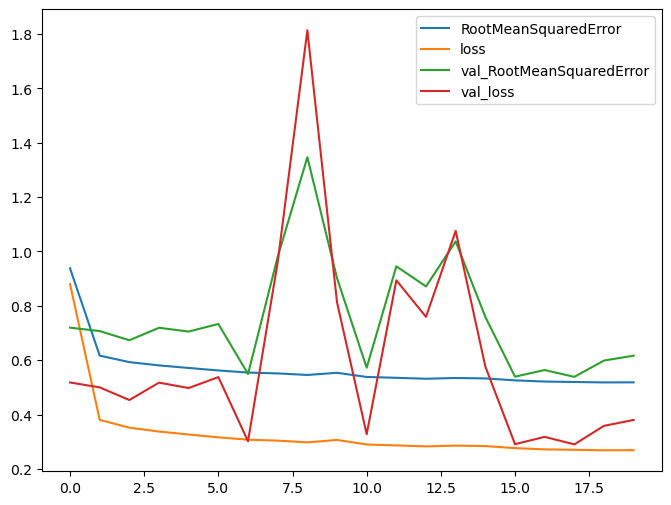

In [54]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(range(20), history.history['RootMeanSquaredError'], label='RootMeanSquaredError')
plt.plot(range(20), history.history['loss'], label='loss')
plt.plot(range(20), history.history['val_RootMeanSquaredError'], label='val_RootMeanSquaredError')
plt.plot(range(20), history.history['val_loss'], label='val_loss')
plt.legend()

In [59]:
from sklearn.metrics import r2_score
y_predict = model.predict(x_test)
r2_score(y_test, y_predict)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step


-131953.18984213148

In [60]:
from sklearn.ensemble import RandomForestRegressor

sk_model = RandomForestRegressor(random_state=42)
sk_model.fit(x_train, y_train)
sk_y_predict = sk_model.predict(x_test)
r2_score(y_test, sk_y_predict)

0.8001601142626265

In [61]:
import tensorflow as tf
tf.keras.backend.clear_session()
tf.random.set_seed(42)

input = tf.keras.layers.Input(shape=x_train.shape[1:])

normalizaion_layer = tf.keras.layers.Normalization()

hidden_layer1 = tf.keras.layers.Dense(50, activation='relu')
hidden_layer2 = tf.keras.layers.Dense(50, activation='relu')
hidden_layer3 = tf.keras.layers.Dense(50, activation='relu')

output_layer = tf.keras.layers.Dense(1)
concat_layer = tf.keras.layers.Concatenate()

normalized = normalizaion_layer(input)

hidden1 = hidden_layer1(normalized)
hidden2 = hidden_layer2(hidden1)
hidden3 = hidden_layer3(hidden2)

concat = concat_layer([normalized, hidden3])
output = output_layer(concat)

model = tf.keras.Model(inputs = [input], outputs = [output])

# 파라미터 개수 확인 : 데이터 수에 비해 과도하면 과적합 위험 있기 때문
model.summary() 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 8)         │         17 │ input_layer[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50)        │        450 │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50)        │      2,550 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 50)        │      2,550 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 58)        │          0 │ normalization[0]… │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         59 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,626 (21.98 KB)

 Trainable params: 5,609 (21.91 KB)

 Non-trainable params: 17 (72.00 B)

In [64]:
model.compile(loss='mse', optimizer='adam', metrics=['RootMeanSquaredError'])
normalizaion_layer.adapt(x_train)
history = model.fit(x_train, y_train, epochs=50, validation_data = (x_val, y_val))

Epoch 1/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.8883 - loss: 0.7891 - val_RootMeanSquaredError: 0.6080 - val_loss: 0.3696
Epoch 2/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6040 - loss: 0.3648 - val_RootMeanSquaredError: 0.6268 - val_loss: 0.3929
Epoch 3/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5907 - loss: 0.3489 - val_RootMeanSquaredError: 0.7691 - val_loss: 0.5914
Epoch 4/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5740 - loss: 0.3295 - val_RootMeanSquaredError: 0.5626 - val_loss: 0.3165
Epoch 5/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.5673 - loss: 0.3219 - val_RootMeanSquaredError: 0.9241 - val_loss: 0.8540
Epoch 6/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.5611 - loss: 0.3148 - val_RootMeanSquaredError: 1.1943 - val_loss: 1.4264
Epoch 7/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5651 - los

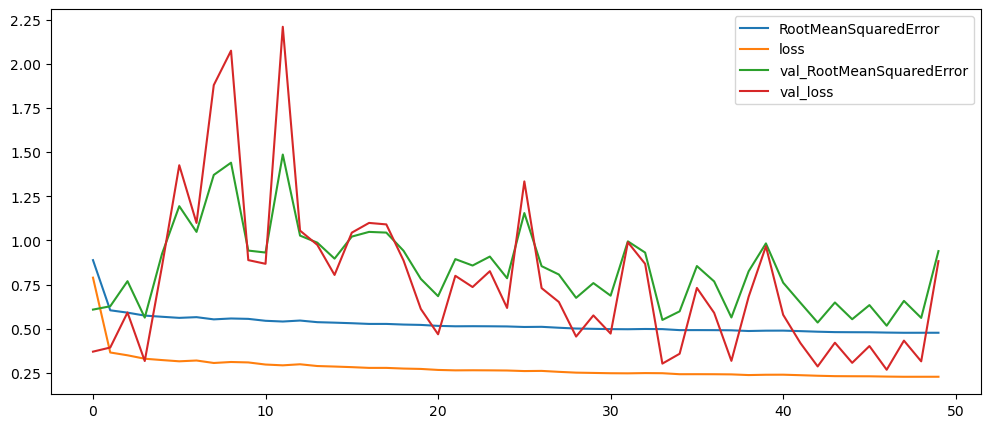

In [65]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(range(50), history.history['RootMeanSquaredError'], label = 'RootMeanSquaredError')
ax.plot(range(50), history.history['loss'], label = 'loss')
ax.plot(range(50), history.history['val_RootMeanSquaredError'], label='val_RootMeanSquaredError')
ax.plot(range(50), history.history['val_loss'], label='val_loss')
ax.legend()
plt.show()

In [66]:
from sklearn.metrics import r2_score
y_predcit = model.predict(x_test)
r2_score(y_test, y_predcit)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step


0.7838560070432271

# 다중 경로

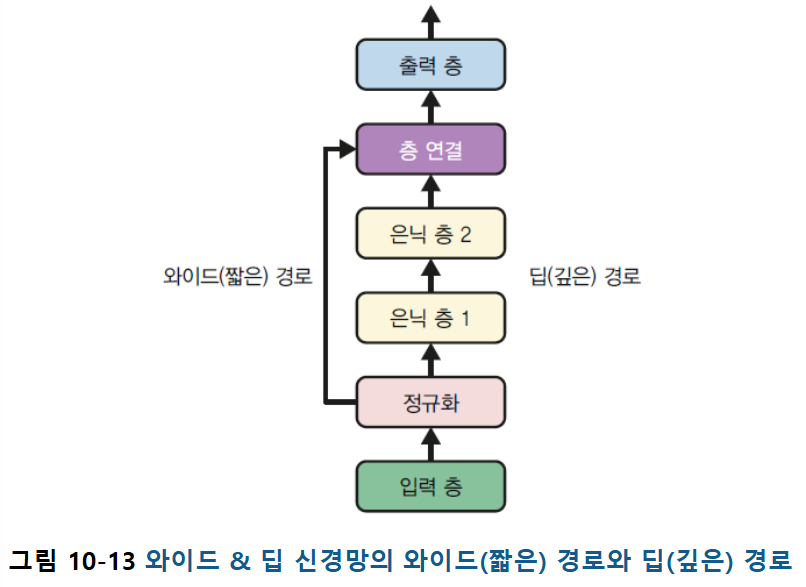

In [71]:
# 다중 경로

x_train_wide, x_train_deep = x_train[:, :5], x_train[:,2:]
x_val_wide, x_val_deep = x_val[:, :5], x_val[:,2:]
x_test_wide, x_test_deep = x_test[:, :5], x_test[:,2:]

input_wide = tf.keras.layers.Input(shape=[5]) # 0 ~ 4 특성
input_deep = tf.keras.layers.Input(shape=[6]) # 2 ~ 7 특성

norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()

norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)

hidden1 = tf.keras.layers.Dense(30, activation='relu')(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation='relu')(hidden1)

concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)

# 보조층 출력
aux_output = tf.keras.layers.Dense(1)(hidden2)

# 모델 생성
model = tf.keras.Model(inputs = [input_wide, input_deep], outputs = [output, aux_output])

# 옵티마이저
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# 컴파일
model.compile(loss=('mse', 'mse'), loss_weights=(0.9, 0.1), optimizer=optimizer, metrics=['RootMeanSquaredError', 'RootMeanSquaredError'])

# 정규화
norm_layer_wide.adapt(x_train_wide)
norm_layer_deep.adapt(x_train_deep)
history = model.fit(
    (x_train_wide, x_train_deep), (y_train, y_train), epochs=20,
    validation_data = ((x_val_wide, x_val_deep), (y_val, y_val))
)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - dense_14_RootMeanSquaredError: 1.2878 - dense_14_loss: 1.6578 - dense_15_RootMeanSquaredError: 1.4274 - dense_15_loss: 2.0368 - loss: 1.6963 - val_dense_14_RootMeanSquaredError: 0.7894 - val_dense_14_loss: 0.6230 - val_dense_15_RootMeanSquaredError: 2.3937 - val_dense_15_loss: 5.7269 - val_loss: 1.1338
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_14_RootMeanSquaredError: 0.7304 - dense_14_loss: 0.5335 - dense_15_RootMeanSquaredError: 0.8496 - dense_15_loss: 0.7218 - loss: 0.5524 - val_dense_14_RootMeanSquaredError: 0.6686 - val_dense_14_loss: 0.4469 - val_dense_15_RootMeanSquaredError: 1.3378 - val_dense_15_loss: 1.7890 - val_loss: 0.5813
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_14_RootMeanSquaredError: 0.6751 - dense_14_loss: 0.4559 - dense_15_RootMeanSquaredError: 0.7715 - dense_15_loss: 0.5952 - loss: 0.4698 - val_dense_14_RootMeanSquaredError: 0.6401 - val_dense_14_loss: 0.4096 - val_dense_15_Ro

In [75]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_6     │ (None, 6)         │         13 │ input_layer_6[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 30)        │        210 │ normalization_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_5     │ (None, 5)         │         11 │ input_layer_5[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 30)        │        930 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 35)        │          0 │ normalization_5[… │
│ (Concatenate)       │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1)         │         36 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │         31 │ dense_13[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,647 (14.26 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 24 (104.00 B)

 Optimizer params: 2,416 (9.44 KB)

In [76]:
model.evaluate( (x_test_wide, x_test_deep),(y_test,y_test) )

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step - dense_14_RootMeanSquaredError: 0.5707 - dense_14_loss: 0.3253 - dense_15_RootMeanSquaredError: 0.6169 - dense_15_loss: 0.3808 - loss: 0.3312


[0.33120882511138916,
 0.3253398537635803,
 0.38076114654541016,
 0.5707287788391113,
 0.6168522238731384]

In [73]:
model.predict((x_test_wide, x_test_deep))

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step


[array([[0.41859567],
        [1.2588115 ],
        [3.7077997 ],
        ...,
        [1.4906433 ],
        [2.4497561 ],
        [4.014973  ]], shape=(5160, 1), dtype=float32),
 array([[0.49492294],
        [1.0993054 ],
        [3.5430062 ],
        ...,
        [1.464113  ],
        [2.1855922 ],
        [3.62487   ]], shape=(5160, 1), dtype=float32)]

In [74]:
y_test

array([0.477  , 0.458  , 5.00001, ..., 1.177  , 2.631  , 4.815  ],
      shape=(5160,))